# 01: Exploratory Data Analysis

Before I extract a single feature, I want to know:

1. **What does the data actually look like?** Channel count, sample rate, duration per subject.
2. **Is the class distribution balanced?** Imbalance changes how I score and which model I pick.
3. **How clean is it?** Any missing values, gaps, or sensor dropouts I need to handle.
4. **Are the activities visually distinguishable in the raw signals?** If walking and cycling already look obviously different on an accelerometer trace, then a hand-crafted feature pipeline is on the right track. If they look identical to the eye, I need to lean harder on frequency-domain or rotational features.

This notebook is a thin wrapper over `src/preprocessing.py`. The same code runs in tests.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG
from src import preprocessing as pp

## Load the raw dataset

If you haven't downloaded it yet, run `python data/download_data.py` from the project root.

In [2]:
path = CONFIG.DATA_PATHS['raw'] / 'pamap2.csv'
df = pp.load_data(path)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2872533, 10)
Columns: ['timestamp', 'activity_id', 'subject_id', 'heart_rate', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z']


,timestamp,activity_id,subject_id,heart_rate,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_gyro_x,hand_gyro_y,hand_gyro_z
0,8.38,0,101,104.0,2.37223,8.60074,3.51048,-0.092217,0.056812,-0.015845
1,8.39,0,101,NaN,2.18837,8.56560,3.66179,-0.024413,0.047759,0.006474
2,8.40,0,101,NaN,2.37357,8.60107,3.54898,-0.057976,0.032574,-0.006988
3,8.41,0,101,NaN,2.07473,8.52853,3.66021,-0.002352,0.032810,-0.003747
4,8.42,0,101,NaN,2.22936,8.83122,3.70000,0.012269,0.018305,-0.053325


## Class balance

If one exercise dominates the dataset, accuracy alone will be misleading. I'll use macro-F1 alongside accuracy from here on, but it's still worth knowing the shape of the imbalance.

activity_id
0     929661
1     192523
2     185188
3     189931
4     238761
5      98199
6     164600
7     188107
12    117216
13    104944
16    175353
17    238690
24     49360
Name: count, dtype: int64


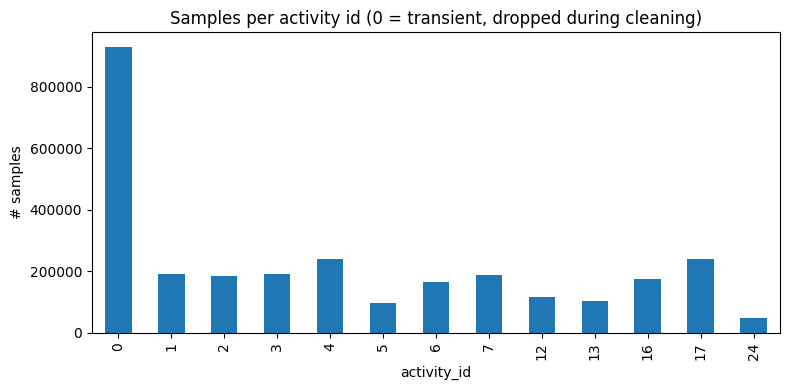

In [3]:
label_col = CONFIG.LABEL_COL
class_counts = df[label_col].value_counts().sort_index()
print(class_counts)

fig, ax = plt.subplots(figsize=(8,4))
class_counts.plot(kind='bar', ax=ax)
plt.title('Samples per activity id (0 = transient, dropped during cleaning)')
plt.xlabel('activity_id')
plt.ylabel('# samples')
plt.tight_layout()
plt.show()

## Missing data

IMU dropouts are common when a sensor briefly loses contact or the wireless link stutters.

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print('No missing values.')
else:
    print(missing)

heart_rate      2610265
hand_acc16_x      13141
hand_acc16_y      13141
hand_acc16_z      13141
hand_gyro_x       13141
hand_gyro_y       13141
hand_gyro_z       13141
dtype: int64


## Drop transients and inspect a single rep window

Now I drop activity id 0 (rest periods) and look at one window of one subject doing one exercise. The expected pattern: accelerometer traces oscillate at the rep frequency, gyroscope channels light up on whichever axis the joint is rotating around, heart rate drifts slowly upward across a working set.

Cleaned shape: (1942872, 10)
First subject: 101, first activity: 1
Signal slice shape: (1000, 10)


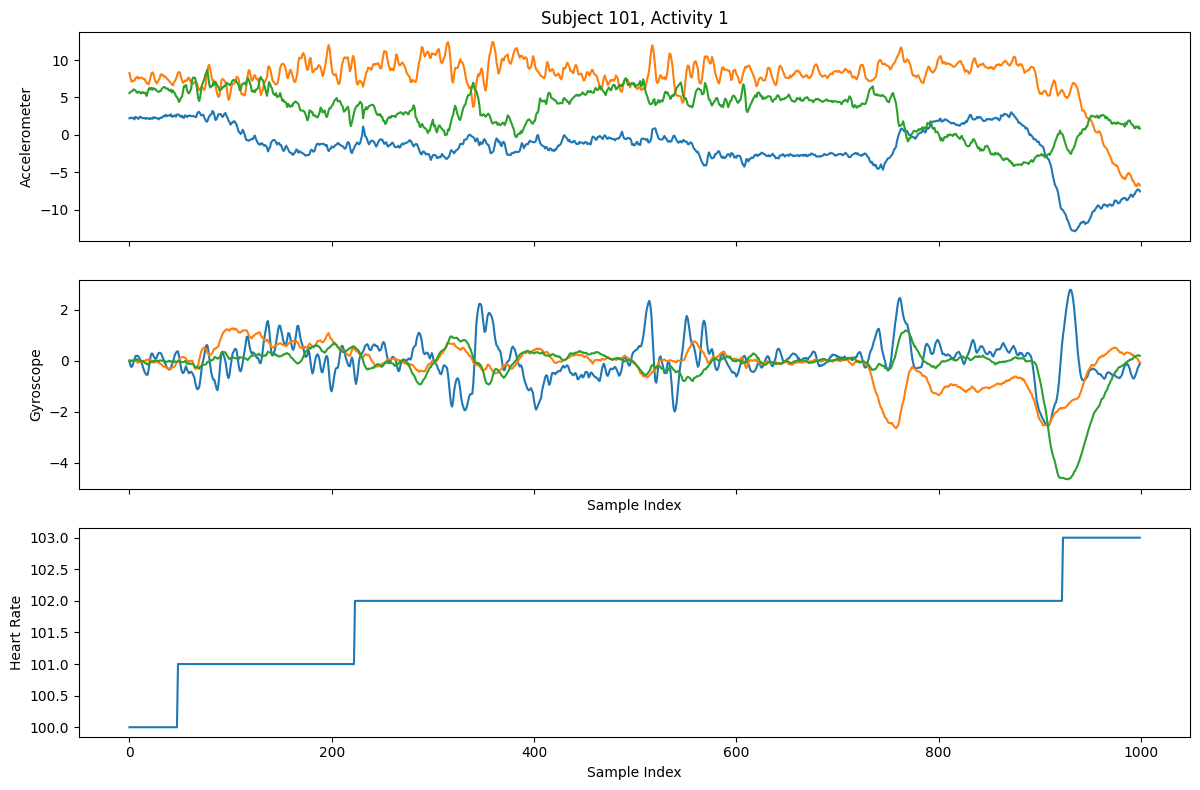

In [5]:
df_clean = pp.clean(df)
df_clean = pp.interpolate_missing(df_clean)
print(f'Cleaned shape: {df_clean.shape}')

subj = df_clean[CONFIG.SUBJECT_COL].iloc[0]
act = df_clean.loc[df_clean[CONFIG.SUBJECT_COL] == subj, CONFIG.LABEL_COL].iloc[0]
print(f'First subject: {subj}, first activity: {act}')

slice_ = df_clean[
    (df_clean[CONFIG.SUBJECT_COL] == subj) &
    (df_clean[CONFIG.LABEL_COL] == act)
].head(CONFIG.SAMPLE_RATE * 10)
print(f'Signal slice shape: {slice_.shape}')

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(slice_[CONFIG.FEATURE_COLS[:3]])
ax[0].set_ylabel('Accelerometer')
ax[0].set_title(f'Subject {subj}, Activity {act}')

ax[1].plot(slice_[CONFIG.FEATURE_COLS[3:6]])
ax[1].set_ylabel('Gyroscope')
ax[1].set_xlabel('Sample Index')

ax[2].plot(slice_[CONFIG.FEATURE_COLS[6]])
ax[2].set_ylabel('Heart Rate')
ax[2].set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

## Frequency content

The rep cadence should show up as a peak somewhere in the 0.3 to 2 Hz band, depending on tempo. Seeing that peak in the FFT is a quick sanity check that frequency-domain features will carry signal.

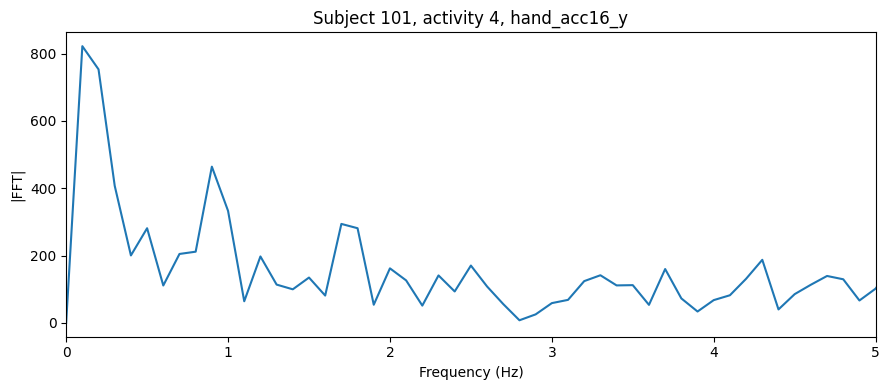

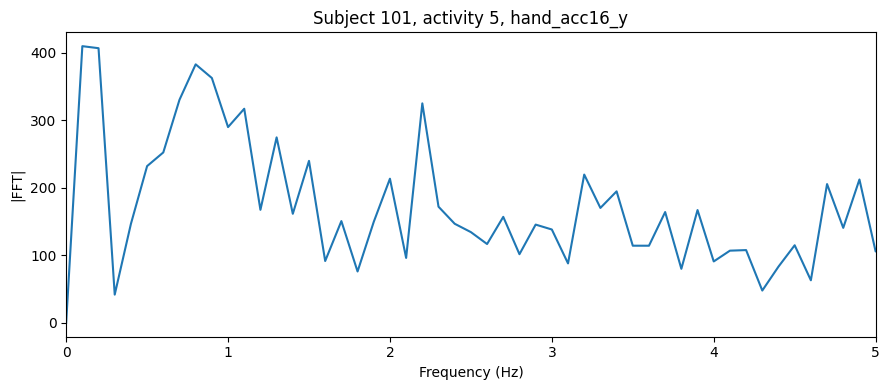

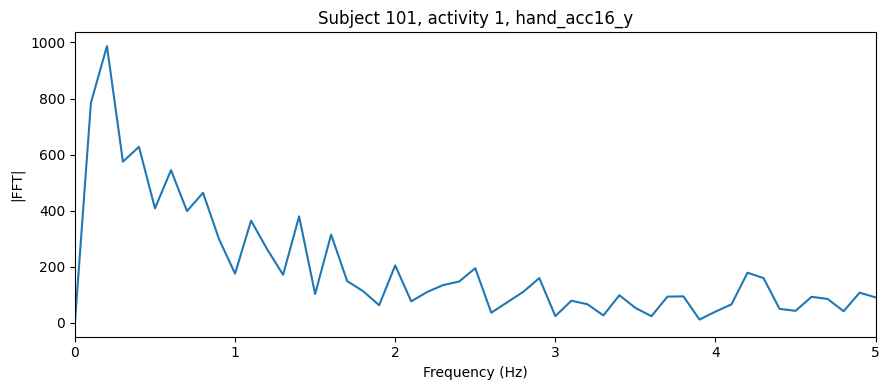

In [7]:
def show_signals_and_spectrum(subj, act, channel='hand_acc16_y'):
    slice_ = df_clean[
        (df_clean[CONFIG.SUBJECT_COL] == subj) &
        (df_clean[CONFIG.LABEL_COL] == act)
    ].head(CONFIG.SAMPLE_RATE * 10)

    if slice_.empty:
        print(f'No data for subject {subj}, activity {act}.')
        return

    sig = slice_[channel].to_numpy() - slice_[channel].mean()
    freqs = np.fft.rfftfreq(len(sig), d=1.0 / CONFIG.SAMPLE_RATE)
    spectrum = np.abs(np.fft.rfft(sig))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(freqs, spectrum)
    ax.set_xlim(0, 5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|FFT|')
    ax.set_title(f'Subject {subj}, activity {act}, {channel}')
    plt.tight_layout(); plt.show()

show_signals_and_spectrum(101, 4)   # walking
show_signals_and_spectrum(101, 5)   # running
show_signals_and_spectrum(101, 1)   # lying

## Takeaways

- **Class balance**: 12 labelled activities. Mildly imbalanced, about 5:1 between the biggest class (walking, ironing) and the smallest (rope jumping). Activity 0 (transient) dominates raw counts but gets dropped during cleaning. Macro-F1 will be a more honest metric than raw accuracy here.

- **Missing data**: heart rate is NaN in 91% of rows because PAMAP2 logs HR at 9 Hz against the IMU's 100 Hz. That's a sample-rate mismatch, not corruption. Forward fill handles it cleanly, which is what produces the step pattern visible in the heart rate panel above. The IMU columns each have around 13k missing rows (about 0.5%) from brief sensor dropouts, also handled by interpolation.

- **Visible class differences**: walking shows a clear rhythmic peak in the FFT around 1 to 2 Hz, running pushes that closer to 2.2 Hz. Lying is essentially flat. Dominant frequency is going to be a useful feature for the locomotion classes, less so for postural ones (lying, sitting, standing) where I'll need to lean on amplitude and gyroscope features instead.

- **CONFIG match**: column names, label column, subject column, and transient label all line up with PAMAP2's actual schema. No CONFIG changes needed before moving on to feature extraction.
